In [1]:
import os
os.chdir('/Users/zolf/Desktop/genomics')

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


In [5]:
# 1. Load your data
path_to_csv = "Genomic data Updated.csv"  # change path if needed
df = pd.read_csv(path_to_csv)

# Just to check:
print(df.shape)
print(df.columns[-10:])  # last columns (Age, MOPS, IRI, crimes, PCL-R)

(638, 137)
Index(['MOPS Total Score', 'MOPS Mother Score', 'MOPS Father Score', 'IRI_PT',
       'IRI_FS', 'IRI_EC', 'IRI_PD', 'IRI_Total scores', 'Homicide',
       'Violent Crime'],
      dtype='object')


In [7]:
# ============================================
# 2. FILTER PCL-R AND CREATE BINARY TARGET
# ============================================
# Keep only PCL-R = 1 or 3 and create PCL_Binary
df_bin = df[df["Classification of Total PCL-R Score"].isin([1, 3])].copy()

print("=== STEP 2: FILTERED PCL-R = 1 OR 3 ===")
print("Shape after filter:", df_bin.shape)
print("PCL-R distribution:", df_bin["Classification of Total PCL-R Score"].value_counts().to_dict())

df_bin["PCL_Binary"] = df_bin["Classification of Total PCL-R Score"].map({1: 0, 3: 1})
print("PCL_Binary distribution:", df_bin["PCL_Binary"].value_counts().to_dict())
print()

=== STEP 2: FILTERED PCL-R = 1 OR 3 ===
Shape after filter: (385, 137)
PCL-R distribution: {1.0: 314, 3.0: 71}
PCL_Binary distribution: {0: 314, 1: 71}



In [9]:
# ============================================
# 3. IDENTIFY AND ENCODE SNP COLUMNS
# ============================================

import numpy as np
import pandas as pd

# All SNP columns start with "rs"
snp_cols = [c for c in df_bin.columns if c.startswith("rs")]

print("=== STEP 3: SNP COLUMNS DETECTED ===")
print("Number of SNP columns:", len(snp_cols))
print("First 10 SNP columns:", snp_cols[:10])
print()

def encode_snp_additive(series: pd.Series) -> pd.Series:
    """
    Encode SNP genotypes (e.g., 'AA', 'AG', 'GG', 'TC') as 0/1/2
    = number of copies of a 'minor' allele (chosen consistently).
    """
    s = series.dropna().astype(str).str.strip()
    if s.empty:
        return series.astype(float)

    # Get all alleles present in this SNP (A/C/G/T)
    alleles = sorted({allele for geno in s for allele in geno if allele != '-'})
    if len(alleles) == 0:
        # Fallback: try convert to numeric
        return pd.to_numeric(series, errors='coerce')

    # Choose minor allele as the second in sorted list (arbitrary but consistent)
    minor = alleles[0] if len(alleles) == 1 else alleles[1]

    def map_geno(g):
        if pd.isna(g):
            return np.nan
        g = str(g).strip()
        if len(g) == 0:
            return np.nan

        # Keep only valid alleles
        g = ''.join([a for a in g if a in alleles])
        if len(g) == 0:
            return np.nan

        # Count copies of minor allele
        return g.count(minor)

    return series.apply(map_geno)

# Apply encoding to all SNP columns in df_bin
df_bin[snp_cols] = df_bin[snp_cols].apply(encode_snp_additive)

print("SNP dtypes after encoding:", df_bin[snp_cols].dtypes.unique())
print()


=== STEP 3: SNP COLUMNS DETECTED ===
Number of SNP columns: 114
First 10 SNP columns: ['rs10057405', 'rs10172965', 'rs10776612', 'rs10995356', 'rs11018023', 'rs11109043', 'rs11163372', 'rs11760485', 'rs11838918', 'rs12494658']

SNP dtypes after encoding: [dtype('float64') dtype('int64')]



In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, LogisticRegressionCV
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, roc_auc_score, confusion_matrix


In [13]:
import numpy as np

# List of PCL target columns that might be stored as text with commas
pcl_cols = ["PCL-R Total Score", "PCL-R Factor 1", "PCL-R Factor 2"]

for col in pcl_cols:
    df_bin[col] = (
        df_bin[col]
        .astype(str)                # treat as string
        .str.strip()                # remove spaces
        .str.replace(",", ".", regex=False)  # replace comma with dot
        .replace({"": np.nan})      # empty strings -> NaN
        .astype(float)              # final conversion to float
    )

print(df_bin[pcl_cols].dtypes)
print(df_bin[pcl_cols].head())


PCL-R Total Score    float64
PCL-R Factor 1       float64
PCL-R Factor 2       float64
dtype: object
   PCL-R Total Score  PCL-R Factor 1  PCL-R Factor 2
0               15.0             5.0             9.0
2               15.0             1.0            12.0
3               31.0            11.0            16.0
4               31.0             9.0            18.0
7               12.0             3.0             9.0


In [15]:
# 1) Correct target column names
target_cols_reg = ["PCL-R Total Score", "PCL-R Factor 1", "PCL-R Factor 2"]
target_col_bin = "PCL_Binary"

# 2) Extra columns to exclude (leakage and non-numeric)
extra_leak_cols = ["Classification of Total PCL-R Score"]
non_numeric_cols = ["URSI", "Race"]  # ID + category

# 3) All columns to drop from X
exclude_cols = target_cols_reg + [target_col_bin] + extra_leak_cols + non_numeric_cols

# 4) Build X and targets
X = df_bin.drop(columns=exclude_cols)

y_total = df_bin["PCL-R Total Score"]
y_f1    = df_bin["PCL-R Factor 1"]
y_f2    = df_bin["PCL-R Factor 2"]
y_bin   = df_bin["PCL_Binary"]

print("X shape:", X.shape)

# leakage check
forbidden = set(exclude_cols)
print("Forbidden ∩ X:", forbidden.intersection(X.columns))


X shape: (385, 131)
Forbidden ∩ X: set()


In [17]:
forbidden = set(target_cols_reg + [target_col_bin] + extra_leak_cols + non_numeric_cols)
print("Forbidden ∩ X columns:", forbidden.intersection(X.columns))


Forbidden ∩ X columns: set()


In [19]:
# Use the imputer+scaler on X
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_trans = preprocessor.fit_transform(X)
print("Any NaN after preprocessing?", np.isnan(X_trans).any())
print("Shape after transform:", X_trans.shape)


Any NaN after preprocessing? False
Shape after transform: (385, 131)


In [21]:
# Percentage of missing values per column
missing_pct = X.isna().mean() * 100

# Sort from highest to lowest missingness
missing_pct_sorted = missing_pct.sort_values(ascending=False)

print("=== Percentage of Missing Values per Column ===")
print(missing_pct_sorted.head(20))   # top 20 most missing


=== Percentage of Missing Values per Column ===
MOPS Total Score         67.792208
MOPS Father Score        67.272727
MOPS Mother Score        65.194805
BIS-11 Factor 3 Score    25.454545
BIS-11 Total Score       25.454545
BIS-11 Factor 1 Score    25.454545
BIS-11 Factor 2 Score    25.454545
IRI_Total scores         23.636364
IRI_PD                   22.597403
IRI_EC                   22.597403
IRI_FS                   22.597403
IRI_PT                   22.337662
rs6471757                 5.454545
rs28606579                5.194805
rs11018023                4.415584
rs1494508                 4.155844
rs539096                  4.155844
rs2763339                 2.597403
rs9326778                 2.597403
rs7387468                 2.337662
dtype: float64


In [23]:
# Psychometric score columns
psych_cols = [
    "MOPS Total Score", "MOPS Father Score", "MOPS Mother Score",
    "BIS-11 Total Score", "BIS-11 Factor 1 Score",
    "BIS-11 Factor 2 Score", "BIS-11 Factor 3 Score",
    "IRI_Total scores", "IRI_PD", "IRI_EC", "IRI_FS", "IRI_PT"
]

# SNP columns (already detected before)
snp_cols_low_missing = [
    "rs6471757", "rs28606579", "rs11018023", "rs1494508",
    "rs539096", "rs2763339", "rs9326778", "rs7387468"
]


In [25]:
from sklearn.impute import SimpleImputer

# Create imputers
psych_imputer = SimpleImputer(strategy="median")
snp_imputer   = SimpleImputer(strategy="median")

# Apply imputation
X[psych_cols] = psych_imputer.fit_transform(X[psych_cols])
X[snp_cols_low_missing] = snp_imputer.fit_transform(X[snp_cols_low_missing])


In [27]:
print("Any NaNs left?", X.isna().any().any())


Any NaNs left? True


In [29]:
# Columns that still contain NaNs
cols_with_nan = X.columns[X.isna().any()]

print("Columns still containing NaNs:")
print(cols_with_nan.tolist())

# Percentage of NaNs in those columns
print("\nMissing percentage:")
print((X[cols_with_nan].isna().mean() * 100).sort_values(ascending=False))


Columns still containing NaNs:
['rs10057405', 'rs10172965', 'rs1256531', 'rs1550057', 'rs17608059', 'rs17680945', 'rs1861046', 'rs1996720', 'rs2301227', 'rs3136202', 'rs4434872', 'rs4792394', 'rs588997', 'rs6502888', 'rs7581919', 'rs8179116', 'rs422343', 'rs1913223', 'rs2523386', 'rs2844833', 'rs6747093', 'rs73060592', 'rs730858', 'rs75740990', 'rs78440419', 'rs2279829', 'rs35068223', 'rs1141090', 'rs10486743', 'rs12529935', 'rs17290504', 'rs62063007', 'rs76315210', 'rs12600304', 'rs2148710', 'rs1446296', 'rs524440', 'rs55946474', 'rs118155936', 'rs102275', 'rs11067376', 'rs4634342', 'rs3772556', 'rs10518544', 'rs6995692', 'rs35219418', 'Intelligence Quotient', 'Homicide', 'Violent Crime']

Missing percentage:
rs10057405               2.337662
rs2301227                2.337662
Homicide                 2.337662
Violent Crime            2.337662
rs12600304               2.077922
rs6747093                1.818182
rs62063007               1.558442
rs1861046                1.298701
rs757409

In [31]:
from sklearn.impute import SimpleImputer

# Identify remaining columns with NaNs
cols_with_nan = X.columns[X.isna().any()]

print("Imputing these columns:")
print(cols_with_nan.tolist())

# Median imputation for all remaining NaNs
final_imputer = SimpleImputer(strategy="median")

X[cols_with_nan] = final_imputer.fit_transform(X[cols_with_nan])

# Final check
print("Any NaNs left?", X.isna().any().any())


Imputing these columns:
['rs10057405', 'rs10172965', 'rs1256531', 'rs1550057', 'rs17608059', 'rs17680945', 'rs1861046', 'rs1996720', 'rs2301227', 'rs3136202', 'rs4434872', 'rs4792394', 'rs588997', 'rs6502888', 'rs7581919', 'rs8179116', 'rs422343', 'rs1913223', 'rs2523386', 'rs2844833', 'rs6747093', 'rs73060592', 'rs730858', 'rs75740990', 'rs78440419', 'rs2279829', 'rs35068223', 'rs1141090', 'rs10486743', 'rs12529935', 'rs17290504', 'rs62063007', 'rs76315210', 'rs12600304', 'rs2148710', 'rs1446296', 'rs524440', 'rs55946474', 'rs118155936', 'rs102275', 'rs11067376', 'rs4634342', 'rs3772556', 'rs10518544', 'rs6995692', 'rs35219418', 'Intelligence Quotient', 'Homicide', 'Violent Crime']
Any NaNs left? False


In [33]:
print("Missing in y_total:", y_total.isna().sum())
print("Missing in y_f1:", y_f1.isna().sum())
print("Missing in y_f2:", y_f2.isna().sum())


Missing in y_total: 0
Missing in y_f1: 0
Missing in y_f2: 5


In [35]:
median_f1 = df_bin["PCL-R Factor 1"].median()
median_f2 = df_bin["PCL-R Factor 2"].median()

print("Median Factor 1:", median_f1)
print("Median Factor 2:", median_f2)

# Binarize: < median → 0 (low), >= median → 1 (high)
df_bin["PCL_F1_Binary"] = (df_bin["PCL-R Factor 1"] >= median_f1).astype(int)
df_bin["PCL_F2_Binary"] = (df_bin["PCL-R Factor 2"] >= median_f2).astype(int)

# Check distribution
print("\nBinary Factor 1 distribution:")
print(df_bin["PCL_F1_Binary"].value_counts())

print("\nBinary Factor 2 distribution:")
print(df_bin["PCL_F2_Binary"].value_counts())

Median Factor 1: 5.0
Median Factor 2: 11.1

Binary Factor 1 distribution:
PCL_F1_Binary
1    205
0    180
Name: count, dtype: int64

Binary Factor 2 distribution:
PCL_F2_Binary
0    193
1    192
Name: count, dtype: int64


/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/983155323.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin["PCL_F1_Binary"] = (df_bin["PCL-R Factor 1"] >= median_f1).astype(int)
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/983155323.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin["PCL_F2_Binary"] = (df_bin["PCL-R Factor 2"] >= median_f2).astype(int)


In [37]:
y_f1_bin = df_bin["PCL_F1_Binary"]
y_f2_bin = df_bin["PCL_F2_Binary"]

print("y_f1_bin shape:", y_f1_bin.shape)
print("y_f2_bin shape:", y_f2_bin.shape)

y_f1_bin shape: (385,)
y_f2_bin shape: (385,)


In [39]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

clf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l2",
        solver="lbfgs",
        scoring="roc_auc",
        max_iter=500,
        class_weight="balanced",
        random_state=42
    ))
])

clf_pipeline.fit(X_train_bin, y_train_bin)
y_pred_bin = clf_pipeline.predict(X_test_bin)
y_proba_bin = clf_pipeline.predict_proba(X_test_bin)[:, 1]

print("\n=== PCL_Binary – Logistic RegressionCV ===")
print("Accuracy:", round(accuracy_score(y_test_bin, y_pred_bin), 3))
print("ROC AUC:", round(roc_auc_score(y_test_bin, y_proba_bin), 3))
print("Confusion matrix:\n", confusion_matrix(y_test_bin, y_pred_bin))



=== PCL_Binary – Logistic RegressionCV ===
Accuracy: 0.688
ROC AUC: 0.627
Confusion matrix:
 [[46 17]
 [ 7  7]]


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Reusable pipeline
clf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l2",
        solver="lbfgs",
        scoring="roc_auc",
        max_iter=500,
        class_weight="balanced",
        random_state=42
    ))
])

def run_classification_model(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf_pipeline.fit(X_train, y_train)
    y_pred = clf_pipeline.predict(X_test)
    y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

    print(f"\n=== Classification: {label} ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Run for both targets
run_classification_model(X, y_f1_bin, "PCL Factor 1 (Binary)")
run_classification_model(X, y_f2_bin, "PCL Factor 2 (Binary)")


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite


=== Classification: PCL Factor 1 (Binary) ===
Accuracy: 0.481
ROC AUC: 0.521
Confusion matrix:
 [[20 16]
 [24 17]]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Classification: PCL Factor 2 (Binary) ===
Accuracy: 0.558
ROC AUC: 0.6
Confusion matrix:
 [[22 17]
 [17 21]]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# RF pipeline: impute -> RF (no scaling needed for trees)
rf_clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ))
])

def run_rf_classifier(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    rf_clf.fit(X_train, y_train)
    y_pred = rf_clf.predict(X_test)
    y_proba = rf_clf.predict_proba(X_test)[:, 1]
    
    print(f"\n=== Random Forest Classification: {label} ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# 🔁 Run RF on exactly the same design you used for logistic regression
run_rf_classifier(X, y_bin,    "PCL_Binary")
run_rf_classifier(X, y_f1_bin, "PCL Factor 1 (Binary)")
run_rf_classifier(X, y_f2_bin, "PCL Factor 2 (Binary)")



=== Random Forest Classification: PCL_Binary ===
Accuracy: 0.818
ROC AUC: 0.499
Confusion matrix:
 [[63  0]
 [14  0]]

=== Random Forest Classification: PCL Factor 1 (Binary) ===
Accuracy: 0.494
ROC AUC: 0.485
Confusion matrix:
 [[17 19]
 [20 21]]

=== Random Forest Classification: PCL Factor 2 (Binary) ===
Accuracy: 0.558
ROC AUC: 0.611
Confusion matrix:
 [[23 16]
 [18 20]]


In [49]:
forbidden = {
    "PCL-R Total Score", "PCL-R Factor 1", "PCL-R Factor 2",
    "PCL_Binary", "Classification of Total PCL-R Score"
}
print("Forbidden in X:", forbidden.intersection(X.columns))


Forbidden in X: set()


In [51]:
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix
)


In [53]:
results = []


In [55]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, label, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # PRINT
    print(f"\n===== {label} =====")
    print("Accuracy:", round(acc, 3))
    print("F1-score:", round(f1, 3))
    print("ROC AUC:", round(auc, 3) if auc else "N/A")
    print("Sensitivity:", round(sensitivity, 3))
    print("Specificity:", round(specificity, 3))
    print("Confusion matrix:\n", cm)

    # RETURN results dictionary
    return {
        "Target": label.split(" — ")[0],
        "Model": model_name,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }


In [57]:
def run_all_models_for_target(X, y, target_name):
    global results  # store in shared list

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n\n==============================")
    print(f" RUNNING MODELS FOR {target_name}")
    print(f"==============================")

    models = {
        "Gradient Boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(random_state=42))
        ]),
        "KNN (k=5)": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "SVM (RBF)": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42))
        ]),
    }

    for model_name, model in models.items():
        result = evaluate_classifier(
            model, X_train, X_test, y_train, y_test,
            f"{target_name} — {model_name}", model_name
        )
        results.append(result)


In [59]:
results = []

run_all_models_for_target(X, y_bin, "PCL_Binary")
run_all_models_for_target(X, y_f1_bin, "PCL_F1_Binary")
run_all_models_for_target(X, y_f2_bin, "PCL_F2_Binary")




 RUNNING MODELS FOR PCL_Binary

===== PCL_Binary — Gradient Boosting =====
Accuracy: 0.792
F1-score: 0.2
ROC AUC: 0.435
Sensitivity: 0.143
Specificity: 0.937
Confusion matrix:
 [[59  4]
 [12  2]]

===== PCL_Binary — HistGradientBoosting =====
Accuracy: 0.805
F1-score: 0.0
ROC AUC: 0.526
Sensitivity: 0.0
Specificity: 0.984
Confusion matrix:
 [[62  1]
 [14  0]]

===== PCL_Binary — KNN (k=5) =====
Accuracy: 0.779
F1-score: 0.105
ROC AUC: 0.609
Sensitivity: 0.071
Specificity: 0.937
Confusion matrix:
 [[59  4]
 [13  1]]

===== PCL_Binary — SVM (RBF) =====
Accuracy: 0.818
F1-score: 0.0
ROC AUC: 0.554
Sensitivity: 0.0
Specificity: 1.0
Confusion matrix:
 [[63  0]
 [14  0]]


 RUNNING MODELS FOR PCL_F1_Binary

===== PCL_F1_Binary — Gradient Boosting =====
Accuracy: 0.506
F1-score: 0.486
ROC AUC: 0.549
Sensitivity: 0.439
Specificity: 0.583
Confusion matrix:
 [[21 15]
 [23 18]]

===== PCL_F1_Binary — HistGradientBoosting =====
Accuracy: 0.532
F1-score: 0.55
ROC AUC: 0.56
Sensitivity: 0.537
Spec

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

df_res = pd.DataFrame(results)
display(df_res)


,Target,Model,Accuracy,F1,AUC,Sensitivity,Specificity
0,PCL_Binary,Gradient Boosting,0.792208,0.200000,0.435374,0.142857,0.936508
1,PCL_Binary,HistGradientBoosting,0.805195,0.000000,0.526077,0.000000,0.984127
2,PCL_Binary,KNN (k=5),0.779221,0.105263,0.609410,0.071429,0.936508
3,PCL_Binary,SVM (RBF),0.818182,0.000000,0.554422,0.000000,1.000000
4,PCL_F1_Binary,Gradient Boosting,0.506494,0.486486,0.549458,0.439024,0.583333
5,PCL_F1_Binary,HistGradientBoosting,0.532468,0.550000,0.559621,0.536585,0.527778
6,PCL_F1_Binary,KNN (k=5),0.584416,0.644444,0.598916,0.707317,0.444444
7,PCL_F1_Binary,SVM (RBF),0.519481,0.574713,0.487805,0.609756,0.416667
8,PCL_F2_Binary,Gradient Boosting,0.506494,0.486486,0.574899,0.473684,0.538462
9,PCL_F2_Binary,HistGradientBoosting,0.571429,0.602410,0.581646,0.657895,0.487179


In [63]:
# Class counts
class_counts = y_bin.value_counts()

print("Class counts:")
print(class_counts)


Class counts:
PCL_Binary
0    314
1     71
Name: count, dtype: int64


In [65]:
# Class percentages
class_pct = y_bin.value_counts(normalize=True) * 100

print("\nClass percentages:")
print(class_pct.round(2))



Class percentages:
PCL_Binary
0    81.56
1    18.44
Name: proportion, dtype: float64


In [69]:
X = df_bin[snp_cols]
y = y_f2_bin


In [71]:
print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())


X shape: (385, 114)
y distribution:
PCL_F2_Binary
0    193
1    192
Name: count, dtype: int64


In [73]:
X.head()


,rs10057405,rs10172965,rs10776612,rs10995356,rs11018023,rs11109043,rs11163372,rs11760485,rs11838918,rs12494658,...,rs35219418,rs1145247,rs2071303,rs7635829,rs2763339,rs4685500,rs9372149,rs2015436,rs7625357,rs30266
0,1.0,0.0,1,1,2.0,2,2,2,2,2,...,0.0,2,1,1,0.0,0,2,2,1,2
2,1.0,0.0,1,2,2.0,1,0,0,2,1,...,0.0,1,2,1,1.0,0,1,1,1,0
3,0.0,0.0,2,1,2.0,0,0,2,2,2,...,1.0,1,2,2,0.0,0,1,1,2,1
4,0.0,0.0,1,1,2.0,2,0,1,2,2,...,0.0,2,2,1,1.0,0,2,1,0,1
7,1.0,0.0,0,1,1.0,2,0,0,2,0,...,0.0,2,2,2,2.0,1,1,1,0,1


In [75]:
run_all_models_for_target(X, y, "PCL_F2_Binary")




 RUNNING MODELS FOR PCL_F2_Binary

===== PCL_F2_Binary — Gradient Boosting =====
Accuracy: 0.519
F1-score: 0.493
ROC AUC: 0.58
Sensitivity: 0.474
Specificity: 0.564
Confusion matrix:
 [[22 17]
 [20 18]]

===== PCL_F2_Binary — HistGradientBoosting =====
Accuracy: 0.519
F1-score: 0.532
ROC AUC: 0.557
Sensitivity: 0.553
Specificity: 0.487
Confusion matrix:
 [[19 20]
 [17 21]]

===== PCL_F2_Binary — KNN (k=5) =====
Accuracy: 0.481
F1-score: 0.512
ROC AUC: 0.451
Sensitivity: 0.553
Specificity: 0.41
Confusion matrix:
 [[16 23]
 [17 21]]

===== PCL_F2_Binary — SVM (RBF) =====
Accuracy: 0.506
F1-score: 0.486
ROC AUC: 0.494
Sensitivity: 0.474
Specificity: 0.538
Confusion matrix:
 [[21 18]
 [20 18]]


In [77]:
[c for c in df_bin.columns if "PCL" in c.upper()]


['PCL-R Total Score',
 'Classification of Total PCL-R Score',
 'PCL-R Factor 1',
 'PCL-R Factor 2',
 'PCL_Binary',
 'PCL_F1_Binary',
 'PCL_F2_Binary']

In [79]:
target_cols = [
    "PCL-R Total Score",
    "Classification of Total PCL-R Score",
    "PCL-R Factor 1",
    "PCL-R Factor 2",
    "PCL_Binary",
    "PCL_F1_Binary",
    "PCL_F2_Binary"
]


In [83]:
X = df_bin.drop(columns=target_cols)
y = df_bin["PCL_F2_Binary"]


In [85]:
[c for c in X.columns if "PCL" in c.upper()]


[]

In [87]:
[c for c in X.columns if "ID" in c.upper() or "SUBJECT" in c.upper()]


['Homicide']

In [89]:
X.iloc[:, :10].head()   # first 10 columns


,URSI,rs10057405,rs10172965,rs10776612,rs10995356,rs11018023,rs11109043,rs11163372,rs11760485,rs11838918
0,M87100087,1.0,0.0,1,1,2.0,2,2,2,2
2,M87100673,1.0,0.0,1,2,2.0,1,0,0,2
3,M87100776,0.0,0.0,2,1,2.0,0,0,2,2
4,M87100781,0.0,0.0,1,1,2.0,2,0,1,2
7,M87101641,1.0,0.0,0,1,1.0,2,0,0,2


In [91]:
snp_in_X = [c for c in X.columns if c in snp_cols]
non_snp_in_X = [c for c in X.columns if c not in snp_cols]

print("Total X cols:", X.shape[1])
print("SNP cols in X:", len(snp_in_X))
print("Non-SNP cols in X:", len(non_snp_in_X))
print("Non-SNP examples:", non_snp_in_X[:30])


Total X cols: 133
SNP cols in X: 114
Non-SNP cols in X: 19
Non-SNP examples: ['URSI', 'Age', 'Race', 'Hispanic', 'Intelligence Quotient', 'BIS-11 Total Score', 'BIS-11 Factor 1 Score', 'BIS-11 Factor 2 Score', 'BIS-11 Factor 3 Score', 'MOPS Total Score', 'MOPS Mother Score', 'MOPS Father Score', 'IRI_PT', 'IRI_FS', 'IRI_EC', 'IRI_PD', 'IRI_Total scores', 'Homicide', 'Violent Crime']


In [103]:
non_snp_cols = [
    'Age', 'Hispanic', 'Intelligence Quotient',
    'BIS-11 Total Score', 'BIS-11 Factor 1 Score', 'BIS-11 Factor 2 Score', 'BIS-11 Factor 3 Score',
    'MOPS Total Score', 'MOPS Mother Score', 'MOPS Father Score',
    'IRI_PT', 'IRI_FS', 'IRI_EC', 'IRI_PD', 'IRI_Total scores',
    'Homicide', 'Violent Crime'
]

X_non_snp = df_bin[non_snp_cols]
y = df_bin["PCL_F2_Binary"]


In [105]:
print(X_non_snp.shape)
print(X_non_snp.dtypes)
print(y.value_counts())


(385, 17)
Age                        int64
Hispanic                   int64
Intelligence Quotient    float64
BIS-11 Total Score       float64
BIS-11 Factor 1 Score    float64
BIS-11 Factor 2 Score    float64
BIS-11 Factor 3 Score    float64
MOPS Total Score         float64
MOPS Mother Score        float64
MOPS Father Score        float64
IRI_PT                   float64
IRI_FS                   float64
IRI_EC                   float64
IRI_PD                   float64
IRI_Total scores         float64
Homicide                 float64
Violent Crime            float64
dtype: object
PCL_F2_Binary
0    193
1    192
Name: count, dtype: int64


In [107]:
X_non_snp_num = X_non_snp.select_dtypes(include=["number"])
run_all_models_for_target(X_non_snp_num, y, "PCL_F2_Binary")




 RUNNING MODELS FOR PCL_F2_Binary

===== PCL_F2_Binary — Gradient Boosting =====
Accuracy: 0.571
F1-score: 0.548
ROC AUC: 0.644
Sensitivity: 0.526
Specificity: 0.615
Confusion matrix:
 [[24 15]
 [18 20]]

===== PCL_F2_Binary — HistGradientBoosting =====
Accuracy: 0.61
F1-score: 0.625
ROC AUC: 0.689
Sensitivity: 0.658
Specificity: 0.564
Confusion matrix:
 [[22 17]
 [13 25]]

===== PCL_F2_Binary — KNN (k=5) =====
Accuracy: 0.481
F1-score: 0.474
ROC AUC: 0.471
Sensitivity: 0.474
Specificity: 0.487
Confusion matrix:
 [[19 20]
 [20 18]]

===== PCL_F2_Binary — SVM (RBF) =====
Accuracy: 0.571
F1-score: 0.571
ROC AUC: 0.597
Sensitivity: 0.579
Specificity: 0.564
Confusion matrix:
 [[22 17]
 [16 22]]


In [109]:
print("Non-SNP numeric cols:", X_non_snp_num.shape[1])


Non-SNP numeric cols: 17


In [111]:
X_snp = df_bin[snp_cols]

X_combined = pd.concat([X_snp, X_non_snp_num], axis=1)
y = df_bin["PCL_F2_Binary"]


In [113]:
print("Combined X shape:", X_combined.shape)
print("Any PCL leakage?:", [c for c in X_combined.columns if "PCL" in c.upper()])


Combined X shape: (385, 131)
Any PCL leakage?: []


In [117]:
run_all_models_for_target(X_combined, y, "PCL_F2_Binary")




 RUNNING MODELS FOR PCL_F2_Binary

===== PCL_F2_Binary — Gradient Boosting =====
Accuracy: 0.506
F1-score: 0.486
ROC AUC: 0.572
Sensitivity: 0.474
Specificity: 0.538
Confusion matrix:
 [[21 18]
 [20 18]]

===== PCL_F2_Binary — HistGradientBoosting =====
Accuracy: 0.519
F1-score: 0.519
ROC AUC: 0.57
Sensitivity: 0.526
Specificity: 0.513
Confusion matrix:
 [[20 19]
 [18 20]]

===== PCL_F2_Binary — KNN (k=5) =====
Accuracy: 0.545
F1-score: 0.557
ROC AUC: 0.626
Sensitivity: 0.579
Specificity: 0.513
Confusion matrix:
 [[20 19]
 [16 22]]

===== PCL_F2_Binary — SVM (RBF) =====
Accuracy: 0.558
F1-score: 0.541
ROC AUC: 0.583
Sensitivity: 0.526
Specificity: 0.59
Confusion matrix:
 [[23 16]
 [18 20]]


In [119]:
from sklearn.feature_selection import VarianceThreshold

svm_rbf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("var", VarianceThreshold(threshold=0.01)),
    ("model", SVC(probability=True, random_state=42))
])


In [121]:
run_all_models_for_target(X_combined, y, "PCL_F2_Binary")



 RUNNING MODELS FOR PCL_F2_Binary

===== PCL_F2_Binary — Gradient Boosting =====
Accuracy: 0.506
F1-score: 0.486
ROC AUC: 0.572
Sensitivity: 0.474
Specificity: 0.538
Confusion matrix:
 [[21 18]
 [20 18]]

===== PCL_F2_Binary — HistGradientBoosting =====
Accuracy: 0.519
F1-score: 0.519
ROC AUC: 0.57
Sensitivity: 0.526
Specificity: 0.513
Confusion matrix:
 [[20 19]
 [18 20]]

===== PCL_F2_Binary — KNN (k=5) =====
Accuracy: 0.545
F1-score: 0.557
ROC AUC: 0.626
Sensitivity: 0.579
Specificity: 0.513
Confusion matrix:
 [[20 19]
 [16 22]]

===== PCL_F2_Binary — SVM (RBF) =====
Accuracy: 0.558
F1-score: 0.541
ROC AUC: 0.583
Sensitivity: 0.526
Specificity: 0.59
Confusion matrix:
 [[23 16]
 [18 20]]


In [123]:
import pandas as pd
import matplotlib.pyplot as plt

rows = [
    # ===== SNP =====
    {"Feature_Set":"SNP", "Model":"Gradient Boosting",    "Accuracy":0.519, "F1":0.493, "AUC":0.580, "Sensitivity":0.474, "Specificity":0.564},
    {"Feature_Set":"SNP", "Model":"HistGradientBoosting", "Accuracy":0.519, "F1":0.532, "AUC":0.557, "Sensitivity":0.553, "Specificity":0.487},
    {"Feature_Set":"SNP", "Model":"KNN (k=5)",            "Accuracy":0.481, "F1":0.512, "AUC":0.451, "Sensitivity":0.553, "Specificity":0.410},
    {"Feature_Set":"SNP", "Model":"SVM (RBF)",            "Accuracy":0.506, "F1":0.486, "AUC":0.494, "Sensitivity":0.474, "Specificity":0.538},

    # ===== Clinical (Non-SNP) =====
    {"Feature_Set":"Clinical", "Model":"Gradient Boosting",    "Accuracy":0.571, "F1":0.548, "AUC":0.644, "Sensitivity":0.526, "Specificity":0.615},
    {"Feature_Set":"Clinical", "Model":"HistGradientBoosting", "Accuracy":0.610, "F1":0.625, "AUC":0.689, "Sensitivity":0.658, "Specificity":0.564},
    {"Feature_Set":"Clinical", "Model":"KNN (k=5)",           "Accuracy":0.481, "F1":0.474, "AUC":0.471, "Sensitivity":0.474, "Specificity":0.487},
    {"Feature_Set":"Clinical", "Model":"SVM (RBF)",           "Accuracy":0.571, "F1":0.571, "AUC":0.597, "Sensitivity":0.579, "Specificity":0.564},

    # ===== Combined =====
    {"Feature_Set":"Combined", "Model":"Gradient Boosting",    "Accuracy":0.506, "F1":0.486, "AUC":0.572, "Sensitivity":0.474, "Specificity":0.538},
    {"Feature_Set":"Combined", "Model":"HistGradientBoosting", "Accuracy":0.519, "F1":0.519, "AUC":0.570, "Sensitivity":0.526, "Specificity":0.513},
    {"Feature_Set":"Combined", "Model":"KNN (k=5)",           "Accuracy":0.545, "F1":0.557, "AUC":0.626, "Sensitivity":0.579, "Specificity":0.513},
    {"Feature_Set":"Combined", "Model":"SVM (RBF)",           "Accuracy":0.558, "F1":0.541, "AUC":0.583, "Sensitivity":0.526, "Specificity":0.590},
]

df = pd.DataFrame(rows)


In [125]:
df["Feature_Set"] = pd.Categorical(
    df["Feature_Set"],
    categories=["SNP", "Clinical", "Combined"],
    ordered=True
)

df = df.sort_values(["Model", "Feature_Set"]).reset_index(drop=True)

df_rounded = df.copy()
for col in ["Accuracy", "F1", "AUC", "Sensitivity", "Specificity"]:
    df_rounded[col] = df_rounded[col].round(3)

df_rounded


,Feature_Set,Model,Accuracy,F1,AUC,Sensitivity,Specificity
0,SNP,Gradient Boosting,0.519,0.493,0.580,0.474,0.564
1,Clinical,Gradient Boosting,0.571,0.548,0.644,0.526,0.615
2,Combined,Gradient Boosting,0.506,0.486,0.572,0.474,0.538
3,SNP,HistGradientBoosting,0.519,0.532,0.557,0.553,0.487
4,Clinical,HistGradientBoosting,0.610,0.625,0.689,0.658,0.564
5,Combined,HistGradientBoosting,0.519,0.519,0.570,0.526,0.513
6,SNP,KNN (k=5),0.481,0.512,0.451,0.553,0.410
7,Clinical,KNN (k=5),0.481,0.474,0.471,0.474,0.487
8,Combined,KNN (k=5),0.545,0.557,0.626,0.579,0.513
9,SNP,SVM (RBF),0.506,0.486,0.494,0.474,0.538


In [127]:
wide = (
    df.pivot(
        index="Model",
        columns="Feature_Set",
        values=["Accuracy", "F1", "AUC", "Sensitivity", "Specificity"]
    )
    .round(3)
)

wide


Accuracy                       F1                    \
Feature_Set               SNP Clinical Combined    SNP Clinical Combined   
Model                                                                      
Gradient Boosting       0.519    0.571    0.506  0.493    0.548    0.486   
HistGradientBoosting    0.519    0.610    0.519  0.532    0.625    0.519   
KNN (k=5)               0.481    0.481    0.545  0.512    0.474    0.557   
SVM (RBF)               0.506    0.571    0.558  0.486    0.571    0.541   

                        AUC                   Sensitivity                    \
Feature_Set             SNP Clinical Combined         SNP Clinical Combined   
Model                                                                         
Gradient Boosting     0.580    0.644    0.572       0.474    0.526    0.474   
HistGradientBoosting  0.557    0.689    0.570       0.553    0.658    0.526   
KNN (k=5)             0.451    0.471    0.626       0.553    0.474    0.579   
SVM (RBF)             0.494    0.597    0.583       0.474    0.579    0.526   

                     Specificity                    
Feature_Set                  SNP Clinical Combined  
Model                                               
Gradient Boosting          0.564    0.615    0.538  
HistGradientBoosting       0.487    0.564    0.513  
KNN (k=5)                  0.410    0.487    0.513  
SVM (RBF)                  0.538    0.564    0.590

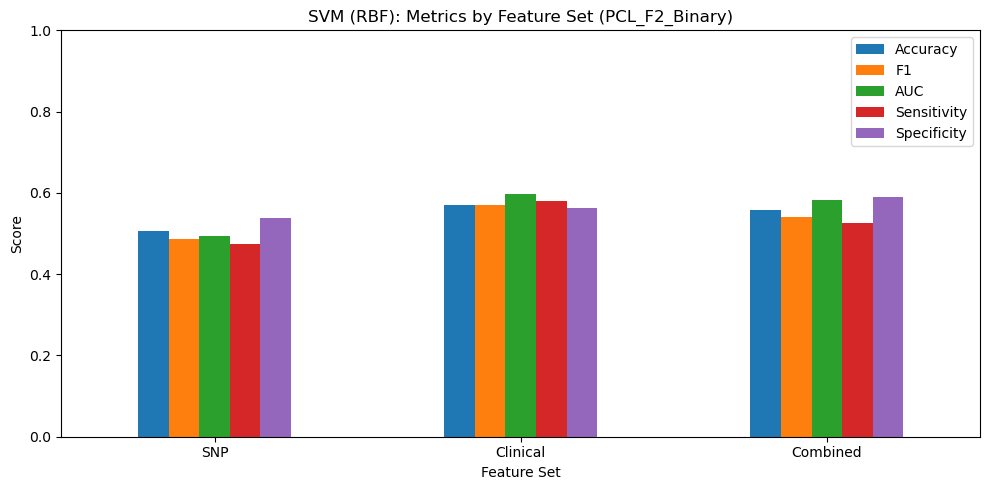

In [129]:
svm = (
    df[df["Model"] == "SVM (RBF)"]
    .set_index("Feature_Set")[["Accuracy", "F1", "AUC", "Sensitivity", "Specificity"]]
    .round(3)
)

ax = svm.plot(kind="bar", figsize=(10, 5))
ax.set_title("SVM (RBF): Metrics by Feature Set (PCL_F2_Binary)")
ax.set_ylabel("Score")
ax.set_xlabel("Feature Set")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [131]:
from sklearn.ensemble import HistGradientBoostingClassifier
import shap
import matplotlib.pyplot as plt


In [133]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def run_svm_shap(
    X, y,
    title="SVM (RBF) SHAP",
    test_size=0.2,
    random_state=42,
    background_size=200,
    explain_size=200,
    max_evals=500
):
    """
    Fits SVM (RBF) pipeline and computes SHAP (PermutationExplainer).
    Returns: (svm_pipe, shap_values, shap_table)
    """

    # Ensure DataFrame to preserve feature names
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    svm_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=random_state))
    ])

    svm_pipe.fit(X_train, y_train)

    # samples for SHAP
    bg = X_train.sample(min(background_size, len(X_train)), random_state=random_state)
    X_explain = X_test.sample(min(explain_size, len(X_test)), random_state=random_state)

    # function to explain: P(class=1)
    def predict_proba_class1(data):
        data = pd.DataFrame(data, columns=X_train.columns)
        return svm_pipe.predict_proba(data)[:, 1]

    explainer = shap.PermutationExplainer(
        predict_proba_class1,
        bg,
        max_evals=max_evals
    )

    shap_values = explainer(X_explain)

    # ---- plots ----
    shap.summary_plot(shap_values, X_explain, show=False)
    plt.title(f"{title} — Summary (beeswarm)")
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
    plt.title(f"{title} — Importance (bar)")
    plt.tight_layout()
    plt.show()

    # ---- importance table ----
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_table = (
        pd.DataFrame({"Feature": X_train.columns, "MeanAbsSHAP": mean_abs_shap})
        .sort_values("MeanAbsSHAP", ascending=False)
        .reset_index(drop=True)
    )

    return svm_pipe, shap_values, shap_table


PermutationExplainer explainer: 78it [00:57,  1.12it/s]                         
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/3643682988.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, show=False)


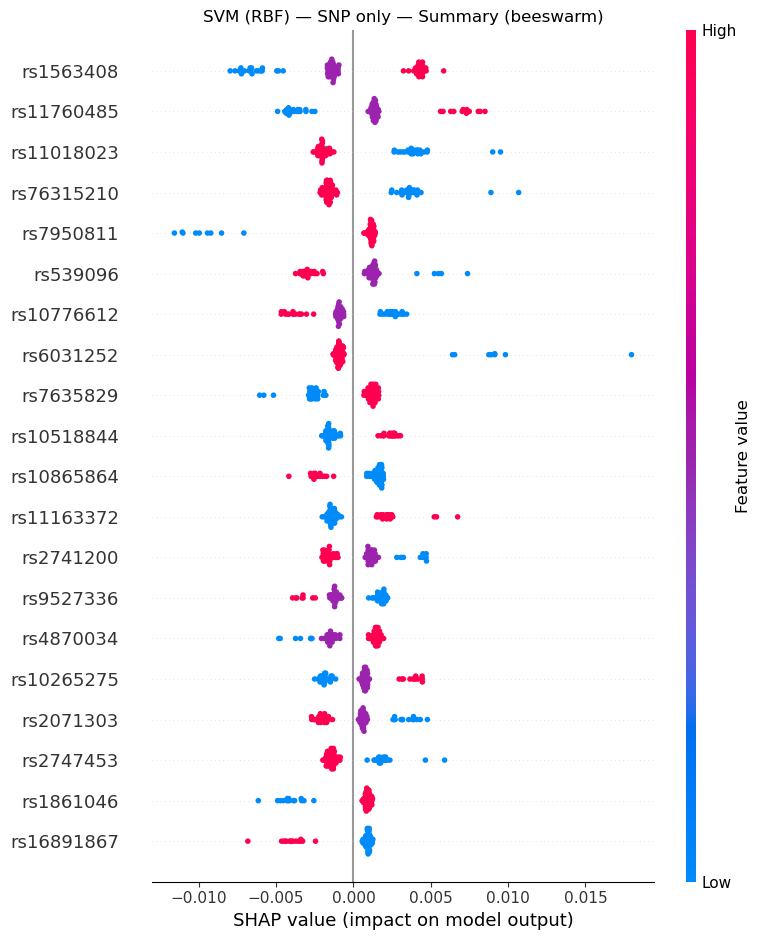

/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/3643682988.py:65: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)


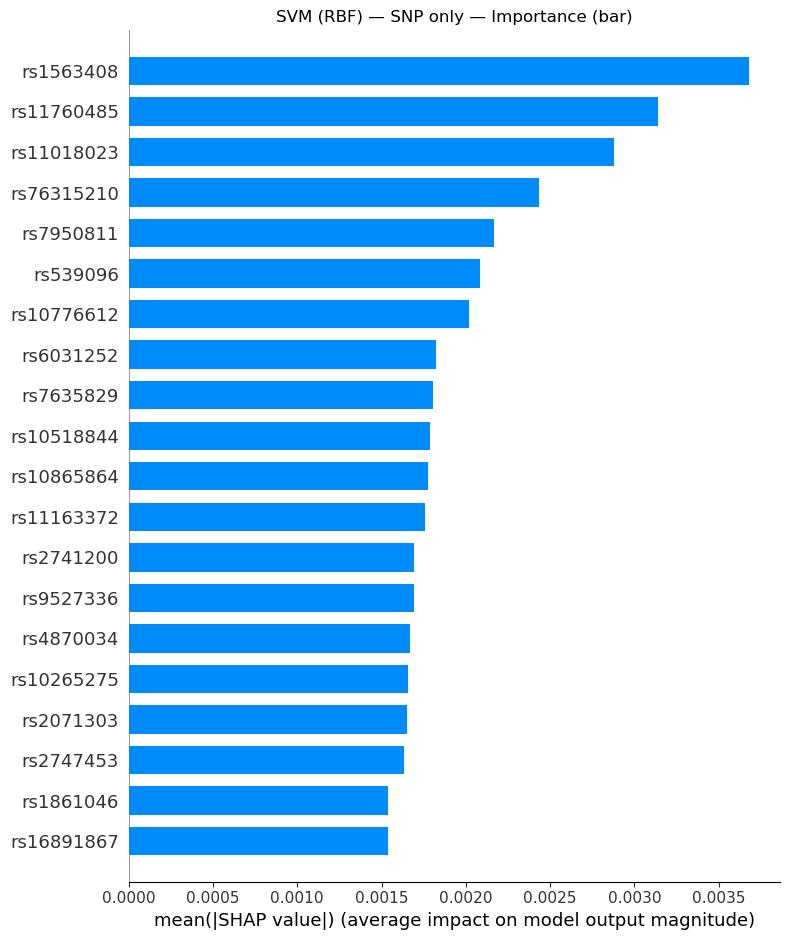

,Feature,MeanAbsSHAP
0,rs1563408,0.003679
1,rs11760485,0.003141
2,rs11018023,0.002879
3,rs76315210,0.002432
4,rs7950811,0.002166
5,rs539096,0.002081
6,rs10776612,0.002019
7,rs6031252,0.001821
8,rs7635829,0.001802
9,rs10518844,0.001787


In [135]:
X_snp = df_bin[snp_cols]
y = df_bin["PCL_F2_Binary"]  # (use this consistently)

svm_snp, shap_snp, table_snp = run_svm_shap(
    X_snp, y,
    title="SVM (RBF) — SNP only"
)

table_snp.head(20)


PermutationExplainer explainer: 78it [00:20,  1.92it/s]                         
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/3643682988.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, show=False)


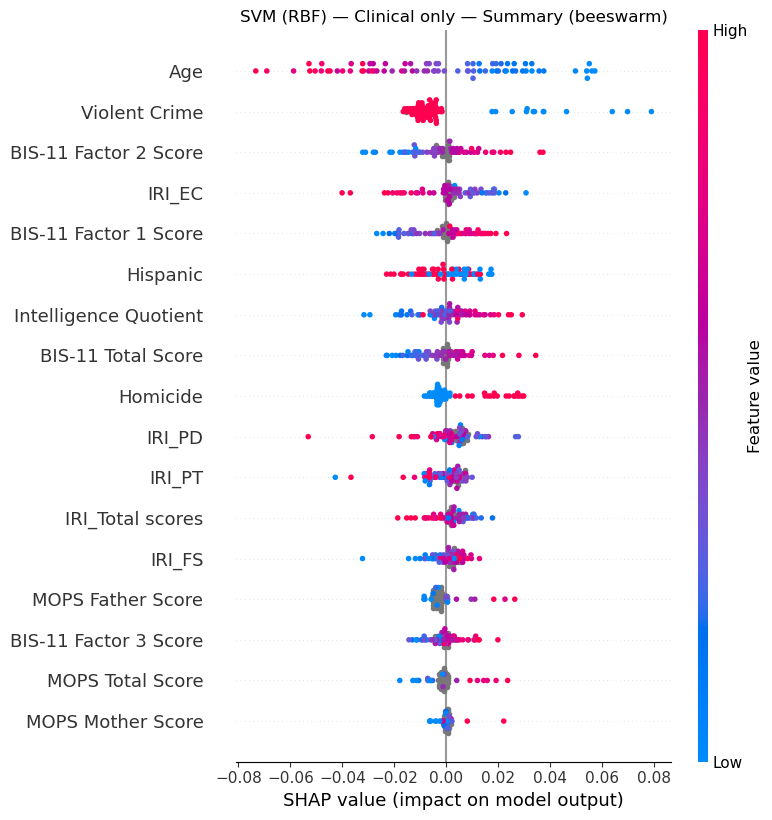

/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/3643682988.py:65: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)


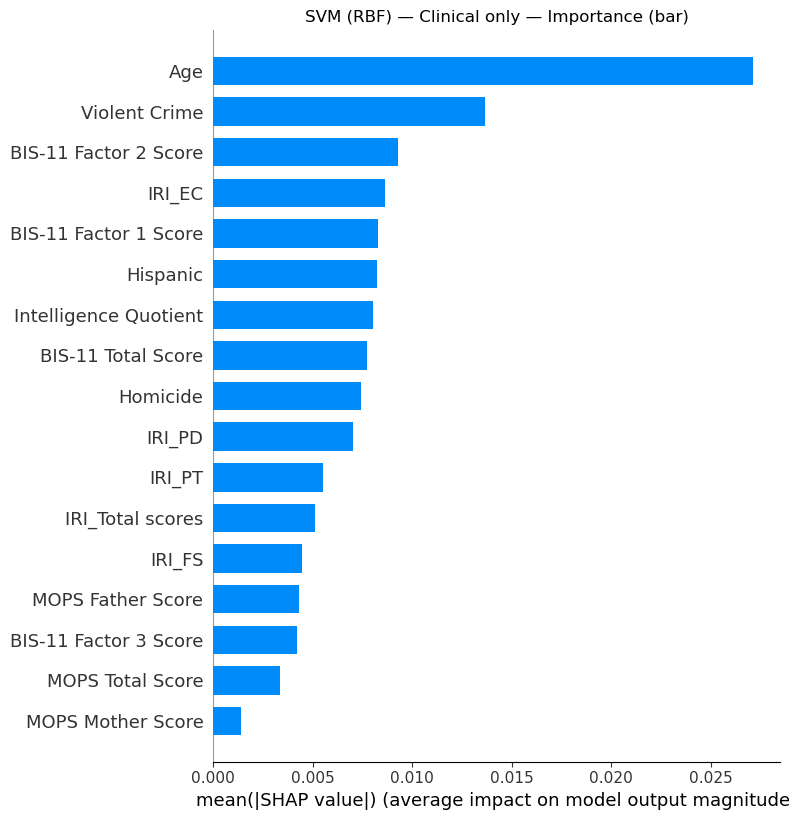

,Feature,MeanAbsSHAP
0,Age,0.027129
1,Violent Crime,0.013667
2,BIS-11 Factor 2 Score,0.009266
3,IRI_EC,0.008648
4,BIS-11 Factor 1 Score,0.008309
5,Hispanic,0.008242
6,Intelligence Quotient,0.008048
7,BIS-11 Total Score,0.007720
8,Homicide,0.007456
9,IRI_PD,0.007024


In [137]:
X_non_snp = df_bin[non_snp_cols]
y = df_bin["PCL_F2_Binary"]

svm_clin, shap_clin, table_clin = run_svm_shap(
    X_non_snp, y,
    title="SVM (RBF) — Clinical only"
)

table_clin.head(20)


PermutationExplainer explainer: 78it [00:40,  1.42it/s]                         
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/3643682988.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, show=False)


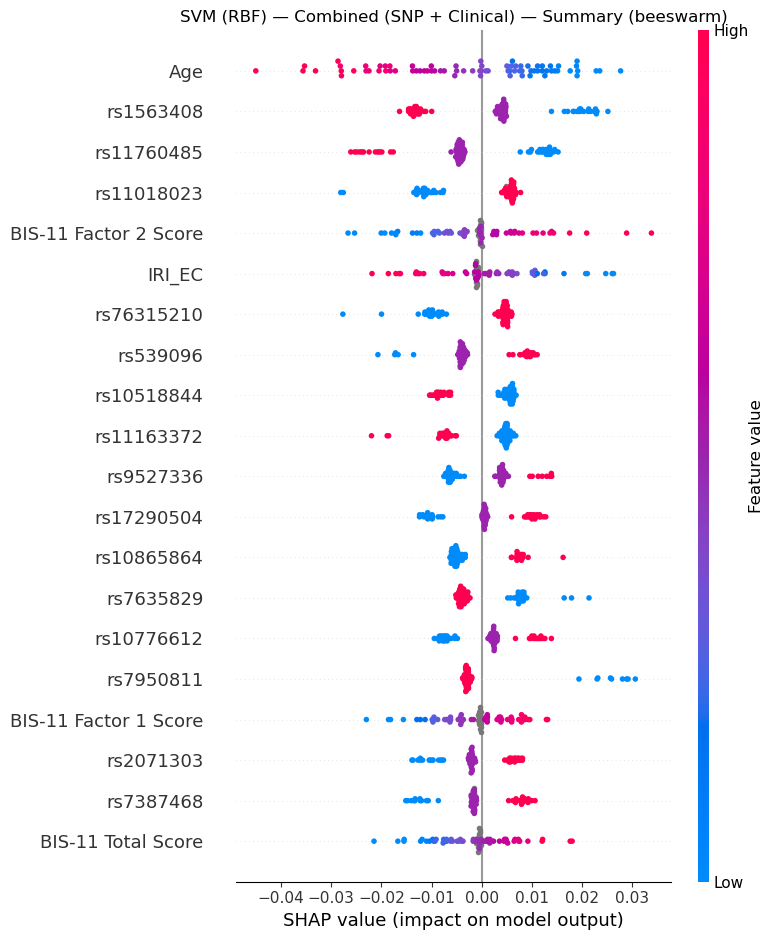

/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_18866/3643682988.py:65: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)


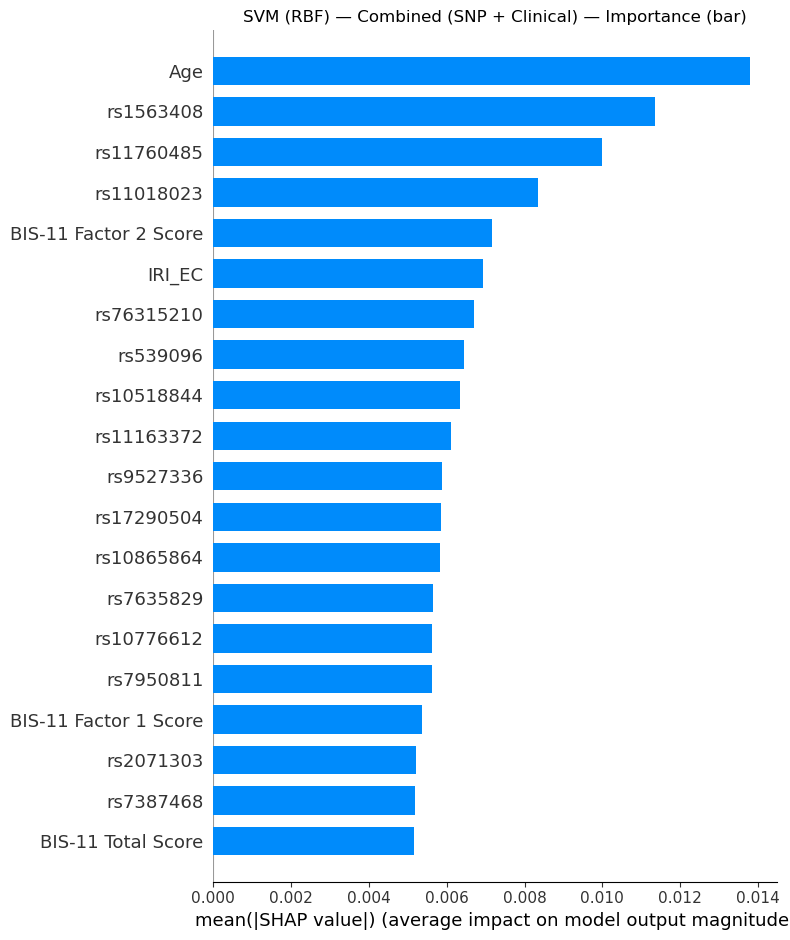

,Feature,MeanAbsSHAP
0,Age,0.013803
1,rs1563408,0.011345
2,rs11760485,0.009984
3,rs11018023,0.008352
4,BIS-11 Factor 2 Score,0.007170
5,IRI_EC,0.006926
6,rs76315210,0.006708
7,rs539096,0.006448
8,rs10518844,0.006354
9,rs11163372,0.006108


In [139]:
X_snp = df_bin[snp_cols]
X_non_snp_num = df_bin[non_snp_cols]   # if already numeric; otherwise use your numeric version
X_combined = pd.concat([X_snp, X_non_snp_num], axis=1)

y = df_bin["PCL_F2_Binary"]

svm_comb, shap_comb, table_comb = run_svm_shap(
    X_combined, y,
    title="SVM (RBF) — Combined (SNP + Clinical)"
)

table_comb.head(20)
